# 2.1 Full EIP-7999 Driven Replay Scaffold

This notebook connects the independent isoelastic demand estimates to the exact block-by-block full-7999 fee transition. It is a mechanics and identification scaffold, not yet a headline volatility comparison.

The central demand benchmark has three independent curves. Joint shocks preserve observed execution/data/state co-movement. Cross-price transaction coupling and capacity coupling are separate sensitivities rather than being hidden inside the shocks.

In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 18,
})
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from demand import (
    JointShockPath,
    ShockEstimationSpec,
    empirical_shock_path,
    estimate_joint_shocks,
    vector_moving_block_bootstrap,
)
from dynamics import (
    IndependentIsoelasticDemand,
    ProportionalBundleCaps,
    SeparateResourceCaps,
    run_driven_full_7999,
    summarize_driven_replay,
)
from mechanisms import make_full_7999_config

pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")

## What is already exact, and what is still empirical work

The replay reuses the exact mechanism transition from notebook 0.9: parent fees govern the current block, the data reserve is active when `data_fee * 12 < blob_fee`, and the resulting excess determines the next block's fee. Execution and data have hard limits; state has a target but no limit.

This first aggregate version discards demand that does not fit. It does not yet model a backlog or select individual transactions. The longer block-frequency shock panel is also still missing. The 120-day observations below identify slow daily demand conditions, but they cannot be repeated as if they were 12-second shocks.

The most important behavioral limitation is explicit: the central calculation scales calldata, BALs, access lists, authorization tuples, and blob hashes together with one data elasticity and one data shock. BAL-producing transactions should respond jointly to execution, data, and state fees, while access-list and authorization activity may respond differently. The elasticity-matrix and bundle-inclusion hooks expose where those sensitivities enter; they do not claim those responses are already identified.

In [2]:
DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)
DATE_LABEL = "2026-02-01_2026-06-01"
GWEI = 1e9
CENTRAL_WINDOW = 35
RESOURCES = ("execution", "data", "state")

ACCOUNTING_CARD_CSV = DATA_DIR / f"full_7999_equilibrium_accounting_card_{DATE_LABEL}.csv"
HEADLINE_CSV = DATA_DIR / f"full_7999_equilibrium_headline_{DATE_LABEL}.csv"
ELASTICITY_CSV = DATA_DIR / "three_way_isoelastic_calibration_2025.csv"
DAILY_ACCOUNTING_CSV = DATA_DIR / f"daily_accounting_panel_calibrated_with_bal_{DATE_LABEL}.csv"
CURRENT_DATA_CSV = DATA_DIR / f"daily_current_data_gas_xatu_{DATE_LABEL}.csv"
OUT_PLOT = PLOTS_DIR / f"full_7999_driven_replay_scaffold_{DATE_LABEL}.png"

accounting_card = pd.read_csv(ACCOUNTING_CARD_CSV).iloc[0]
headline = pd.read_csv(HEADLINE_CSV)
headline = headline[headline["scenario"].isin(["E100_D40_S75", "E200_D60_S75"])].copy()
elasticities = pd.read_csv(ELASTICITY_CSV)
central_elasticity = elasticities.set_index("window_days").loc[CENTRAL_WINDOW]

ANCHOR_METERED_GAS = {
    "execution": float(accounting_card["execution_7999_gas_per_block"]),
    "data": float(accounting_card["data_7999_gas_with_bal_per_block"]),
    "state": float(accounting_card["state_7999_gas_per_block"]),
}
REFERENCE_FEES_WEI = {
    resource: float(accounting_card[f"{resource}_reference_fee_gwei"]) * GWEI
    for resource in RESOURCES
}
ELASTICITIES = {
    resource: float(central_elasticity[f"eps_{resource}"])
    for resource in RESOURCES
}
demand_model = IndependentIsoelasticDemand(
    anchor_metered_gas=ANCHOR_METERED_GAS,
    reference_base_fees_wei=REFERENCE_FEES_WEI,
    elasticities=ELASTICITIES,
)
display(pd.DataFrame({
    "anchor_metered_gas": ANCHOR_METERED_GAS,
    "reference_fee_wei": REFERENCE_FEES_WEI,
    "elasticity": ELASTICITIES,
}))

unit_shock_path = JointShockPath(
    values=pd.DataFrame([[1.0, 1.0, 1.0]], columns=RESOURCES),
    frequency="block", basis="7999_metered",
    source="deterministic warm-start check", source_positions=(0,),
)
warm_start_rows = []
for row in headline.itertuples(index=False):
    targets = {
        "execution": int(row.execution_gas_limit // 2),
        "data": int(row.data_gas_limit // 4),
        "state": int(row.state_gas_target),
    }
    protocol_fees = {
        resource: int(getattr(row, f"{resource}_protocol_base_fee_wei"))
        for resource in RESOURCES
    }
    target_anchored_demand = IndependentIsoelasticDemand(
        anchor_metered_gas=targets,
        reference_base_fees_wei=protocol_fees,
        elasticities=ELASTICITIES,
    )
    reserve_off_config = make_full_7999_config(
        execution_gas_limit=int(row.execution_gas_limit),
        bandwidth_gas_limit=int(row.data_gas_limit),
        state_gas_target=int(row.state_gas_target),
        initial_execution_base_fee=protocol_fees["execution"],
        initial_bandwidth_base_fee=protocol_fees["data"],
        initial_state_base_fee=protocol_fees["state"],
        bandwidth_reserve_factor=0,
    )
    check = run_driven_full_7999(
        config=reserve_off_config, demand_model=target_anchored_demand,
        shock_path=unit_shock_path, blob_base_fee_per_gas=None,
    ).iloc[0]
    for resource in RESOURCES:
        warm_start_rows.append({
            "scenario": row.scenario, "resource": resource,
            "target_gas": targets[resource],
            "current_fee_wei": check[f"{resource}_base_fee_wei"],
            "next_fee_wei": check[f"{resource}_next_base_fee_wei"],
            "fee_unchanged_at_target": (
                check[f"{resource}_base_fee_wei"]
                == check[f"{resource}_next_base_fee_wei"]
            ),
        })
warm_start_validation = pd.DataFrame(warm_start_rows)
if not warm_start_validation["fee_unchanged_at_target"].all():
    raise AssertionError("a notebook-2.0 protocol fee is inconsistent with its excess warm start")
display(warm_start_validation)

,anchor_metered_gas,reference_fee_wei,elasticity
execution,"36,820,725.629258","69,528,565.605298",0.121160
data,"4,241,650.620496","59,442,865.964853",0.229476
state,"29,662,592.274090","18,904,152.013286",0.334864


,scenario,resource,target_gas,current_fee_wei,next_fee_wei,fee_unchanged_at_target
0,E100_D40_S75,execution,50000000,5564776,5564776,True
1,E100_D40_S75,data,10000000,374080,374080,True
2,E100_D40_S75,state,75000000,1184471,1184471,True
3,E200_D60_S75,execution,100000000,18234,18234,True
4,E200_D60_S75,data,15000000,95265,95265,True
5,E200_D60_S75,state,75000000,1184471,1184471,True


## Estimate the daily demand shifter without double-counting price response

For resource $i$, the observed quantity is first de-elasticized: $y_{i,t}=q_{i,t}(p_t/p_i^0)^{\epsilon_i}$. A centered 21-day rolling median of $\log y_{i,t}$ removes the slow trend, and the remaining multiplicative shifter is normalized to have sample mean one. These are implied demand shifters under the estimated elasticity, not causal residuals.

The central shock diagnostic uses historical physical quantities consistent with the elasticity recovery. A later 7999-metered sensitivity can add BAL/access-list/authorization variation, but that behavior is partly imputed rather than separately identified.

In [3]:
daily = pd.read_csv(DAILY_ACCOUNTING_CSV)
current_data = pd.read_csv(CURRENT_DATA_CSV)[["date", "data_gas_current"]]
daily = daily.merge(current_data, on="date", how="inner", validate="one_to_one")
daily["date"] = pd.to_datetime(daily["date"])
if len(daily) != 120 or daily["date"].sort_values().diff().dropna().dt.days.ne(1).any():
    raise ValueError("the daily shock input must contain 120 consecutive dates")
daily["q_execution"] = (
    daily["current_gas_used"]
    - daily["data_gas_current"]
    - daily["current_state_creation_gas_calibrated"]
) / daily["block_count"]
daily["q_data"] = daily["data_gas_current"] / daily["block_count"]
daily["q_state"] = daily["current_state_creation_gas_calibrated"] / daily["block_count"]

daily_spec = ShockEstimationSpec(
    time_col="date",
    usage_cols={resource: f"q_{resource}" for resource in RESOURCES},
    price_cols="median_base_fee_per_gas",
    elasticities=ELASTICITIES,
    frequency="day",
    basis="historical_physical",
    trend_window=21,
)
daily_shock_panel = estimate_joint_shocks(
    daily, daily_spec, source="120-day price-adjusted daily panel"
)
daily_diagnostics = daily_shock_panel.values.corr()
daily_diagnostics.loc["lag_1_acf"] = [
    daily_shock_panel.values[resource].autocorr(lag=1) for resource in RESOURCES
]
display(daily_diagnostics)

try:
    empirical_shock_path(daily_shock_panel).require_block_frequency(step_seconds=12)
except ValueError as error:
    print("Expected frequency guard:", error)

daily_bootstrap_example = vector_moving_block_bootstrap(
    daily_shock_panel, n_steps=120, block_length=7, seed=7999, circular=True
)
print("First two seven-day source windows:", daily_bootstrap_example.source_positions[:14])

,execution,data,state
execution,1.000000,0.543889,0.164168
data,0.543889,1.000000,0.242349
state,0.164168,0.242349,1.000000
lag_1_acf,0.467608,0.522510,0.368189


Expected frequency guard: day-frequency shocks cannot drive a 12-second block replay without explicit disaggregation
First two seven-day source windows: (118, 119, 0, 1, 2, 3, 4, 9, 10, 11, 12, 13, 14, 15)


## Controlled block-frequency mechanics run

Until a longer contiguous block panel is built, the following correlated lognormal shocks are deliberately synthetic. They only test mechanism behavior, warm starts, reserve transitions, and output definitions. They must not be reported as empirical fee-volatility estimates. The same realized shock path is used in every scenario.

In [4]:
N_BLOCKS = 5_000
BURN_IN_BLOCKS = 1_000
RANDOM_SEED = 7999
ILLUSTRATIVE_BLOB_BASE_FEE_WEI = 4_500_000  # controlled input, not an estimate
RESERVE_THRESHOLD_WEI = math.ceil(ILLUSTRATIVE_BLOB_BASE_FEE_WEI / 12)

shock_std = np.array([0.12, 0.18, 0.16])
shock_corr = np.array([
    [1.00, 0.65, 0.15],
    [0.65, 1.00, 0.25],
    [0.15, 0.25, 1.00],
])
shock_cov = np.outer(shock_std, shock_std) * shock_corr
rng = np.random.default_rng(RANDOM_SEED)
shock_values = np.exp(rng.multivariate_normal(np.zeros(3), shock_cov, size=N_BLOCKS))
shock_values = shock_values / shock_values.mean(axis=0)
block_shocks = JointShockPath(
    values=pd.DataFrame(shock_values, columns=RESOURCES),
    frequency="block",
    basis="7999_metered",
    source="controlled correlated lognormal mechanics path",
    source_positions=tuple(range(N_BLOCKS)),
)
block_shocks.values.describe(percentiles=[0.1, 0.5, 0.9])

,execution,data,state
count,"5,000.000000","5,000.000000","5,000.000000"
mean,1.000000,1.000000,1.000000
std,0.120714,0.183202,0.165077
min,0.612142,0.440565,0.583789
10%,0.852883,0.779926,0.798844
50%,0.991218,0.984142,0.985471
90%,1.157012,1.240739,1.219292
max,1.511557,2.014419,1.721411


In [5]:
def scenario_config(row, *, initial_data_fee):
    return make_full_7999_config(
        execution_gas_limit=int(row.execution_gas_limit),
        bandwidth_gas_limit=int(row.data_gas_limit),
        state_gas_target=int(row.state_gas_target),
        execution_target_ratio=2,
        bandwidth_target_ratio=4,
        initial_execution_base_fee=int(row.execution_protocol_base_fee_wei),
        initial_bandwidth_base_fee=int(initial_data_fee),
        initial_state_base_fee=int(row.state_protocol_base_fee_wei),
        bandwidth_reserve_factor=12,
    )

runs = {}
for row in headline.itertuples(index=False):
    starts = {
        "unconstrained equilibrium": int(row.data_protocol_base_fee_wei),
        "reserve threshold": RESERVE_THRESHOLD_WEI,
    }
    for start_name, data_start in starts.items():
        key = (row.scenario, start_name)
        run = run_driven_full_7999(
            config=scenario_config(row, initial_data_fee=data_start),
            demand_model=demand_model,
            shock_path=block_shocks,
            blob_base_fee_per_gas=ILLUSTRATIVE_BLOB_BASE_FEE_WEI,
            inclusion_rule=SeparateResourceCaps(),
            first_block_number=1,
        )
        run.insert(0, "initialization", start_name)
        run.insert(0, "scenario", row.scenario)
        runs[key] = run

len(runs), RESERVE_THRESHOLD_WEI

(4, 375000)

In [6]:
summary_rows = []
for (scenario, initialization), run in runs.items():
    summary = summarize_driven_replay(run, burn_in_blocks=BURN_IN_BLOCKS)
    summary.insert(0, "initialization", initialization)
    summary.insert(0, "scenario", scenario)
    summary_rows.append(summary)
summary = pd.concat(summary_rows, ignore_index=True)
display(summary)

,scenario,initialization,resource,blocks,mean_base_fee_wei,median_base_fee_wei,p90_base_fee_wei,base_fee_log_return_std,mean_included_gas,target_or_above_fraction,own_limit_exceeded_fraction,rationed_fraction,limit_hit_fraction,mean_unserved_gas,reserve_active_fraction,maximum_reserve_run_blocks
0,E100_D40_S75,unconstrained equilibrium,execution,4000,"5,585,459.432500","5,615,047.500000","6,090,721.400000",0.014277,"49,994,897.170250",0.472250,0.000000,0.000000,0.000000,0.000000,NaN,NaN
1,E100_D40_S75,unconstrained equilibrium,data,4000,"1,417,472.076750","1,410,827.000000","1,537,640.400000",0.010873,"9,999,230.144000",0.466500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,E100_D40_S75,unconstrained equilibrium,state,4000,"1,190,581.856750","1,182,821.000000","1,346,856.300000",0.039702,"74,984,148.110500",0.466500,NaN,0.000000,NaN,0.000000,NaN,NaN
3,E100_D40_S75,reserve threshold,execution,4000,"5,585,459.432500","5,615,047.500000","6,090,721.400000",0.014277,"49,994,897.170250",0.472250,0.000000,0.000000,0.000000,0.000000,NaN,NaN
4,E100_D40_S75,reserve threshold,data,4000,"1,417,472.087750","1,410,827.000000","1,537,640.400000",0.010873,"9,999,230.148000",0.466500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,E100_D40_S75,reserve threshold,state,4000,"1,190,581.856750","1,182,821.000000","1,346,856.300000",0.039702,"74,984,148.110500",0.466500,NaN,0.000000,NaN,0.000000,NaN,NaN
6,E200_D60_S75,unconstrained equilibrium,execution,4000,"18,301.457000","18,398.000000","19,957.200000",0.014278,"99,989,794.871750",0.472250,0.000000,0.000000,0.000000,0.000000,NaN,NaN
7,E200_D60_S75,unconstrained equilibrium,data,4000,"382,744.075000","382,710.000000","390,993.900000",0.018051,"13,496,492.592000",0.253250,0.000000,0.000000,0.000000,0.000000,0.129500,1.000000
8,E200_D60_S75,unconstrained equilibrium,state,4000,"1,190,581.856750","1,182,821.000000","1,346,856.300000",0.039702,"74,984,148.110500",0.466500,NaN,0.000000,NaN,0.000000,NaN,NaN
9,E200_D60_S75,reserve threshold,execution,4000,"18,301.457000","18,398.000000","19,957.200000",0.014278,"99,989,794.871750",0.472250,0.000000,0.000000,0.000000,0.000000,NaN,NaN


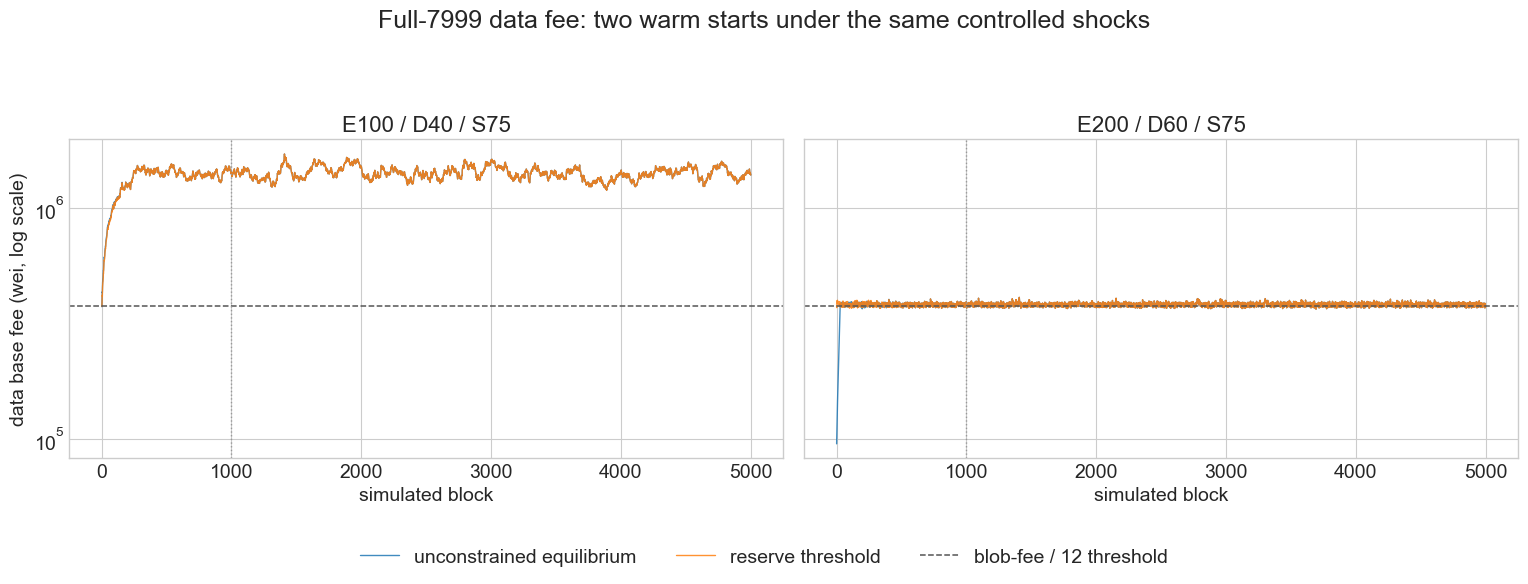

PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/full_7999_driven_replay_scaffold_2026-02-01_2026-06-01.png')

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8), sharey=True)
for ax, scenario in zip(axes, ["E100_D40_S75", "E200_D60_S75"]):
    for initialization in ["unconstrained equilibrium", "reserve threshold"]:
        run = runs[(scenario, initialization)]
        ax.plot(
            run["block_number"],
            run["data_base_fee_wei"],
            linewidth=1.0,
            alpha=0.85,
            label=initialization,
        )
    ax.axhline(
        RESERVE_THRESHOLD_WEI, color="#555555", linestyle="--",
        linewidth=1.1, label="blob-fee / 12 threshold"
    )
    ax.axvline(BURN_IN_BLOCKS, color="#999999", linestyle=":", linewidth=1)
    ax.set_yscale("log")
    ax.set_title(scenario.replace("_", " / "))
    ax.set_xlabel("simulated block")
axes[0].set_ylabel("data base fee (wei, log scale)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.01),
    ncol=3, frameon=False,
)
fig.suptitle("Full-7999 data fee: two warm starts under the same controlled shocks", y=0.98)
fig.tight_layout(rect=(0, 0.09, 1, 0.91))
fig.savefig(OUT_PLOT, dpi=160, bbox_inches="tight")
plt.show()
OUT_PLOT

## Capacity coupling is a separate modeling choice

The central aggregate inclusion rule caps execution and data separately. The fixed-bundle sensitivity below instead scales execution, data, and state together by the tightest hard-limit ratio. This is useful for showing the direction of transaction bundling, but it is intentionally stronger than a real builder that can select transactions with different resource recipes.

In [8]:
stress_path = JointShockPath(
    values=pd.DataFrame([[2.4, 4.5, 2.0]], columns=RESOURCES),
    frequency="block", basis="7999_metered", source="one-block capacity stress",
    source_positions=(0,),
)
stress_row = headline.set_index("scenario").loc["E100_D40_S75"]
stress_runs = []
for rule in [SeparateResourceCaps(), ProportionalBundleCaps()]:
    stress = run_driven_full_7999(
        config=scenario_config(
            stress_row, initial_data_fee=int(stress_row.data_protocol_base_fee_wei)
        ),
        demand_model=demand_model, shock_path=stress_path,
        blob_base_fee_per_gas=ILLUSTRATIVE_BLOB_BASE_FEE_WEI,
        inclusion_rule=rule,
    )
    stress_runs.append(stress)
stress_comparison = pd.concat(stress_runs, ignore_index=True)
display(stress_comparison[[
    "allocation_rule", "bundle_scale", "binding_resources",
    "execution_offered_gas", "execution_included_gas",
    "data_offered_gas", "data_included_gas",
    "state_offered_gas", "state_included_gas", "state_rationed",
]])

,allocation_rule,bundle_scale,binding_resources,execution_offered_gas,execution_included_gas,data_offered_gas,data_included_gas,state_offered_gas,state_included_gas,state_rationed
0,separate_resource_caps,1.000000,"execution,data",120000000,100000000,61073904,40000000,150000007,150000007,False
1,proportional_bundle_caps,0.654944,data,120000000,78593305,61073904,40000000,150000007,98241636,True


## What this establishes, and the next empirical step

1. Notebook 2.0's integer protocol fees can initialize the exact 7999 excess state without an off-by-one fee shift.
2. The blob-linked data reserve is an excess ratchet, not a hard fee floor. Whether the reserve changes the long-run data fee is therefore a dynamic result.
3. The independent demand model, a cross-price matrix model, and the inclusion rule are replaceable components. Joint shocks do not substitute for transaction coupling.
4. The 120-day panel gives daily price-adjusted demand shifters and shows why all three resources must be resampled jointly. It does not identify within-day or block-to-block persistence.
5. Before reporting fee volatility, build a longer contiguous block panel using cheap execution/data/state proxies and calibrated BAL prediction. Then combine its normalized within-day pattern with the daily demand condition, sweep bootstrap window lengths and the 21/35/60/75-day elasticity estimates, and compare Glamsterdam and full 7999 under identical shock draws.